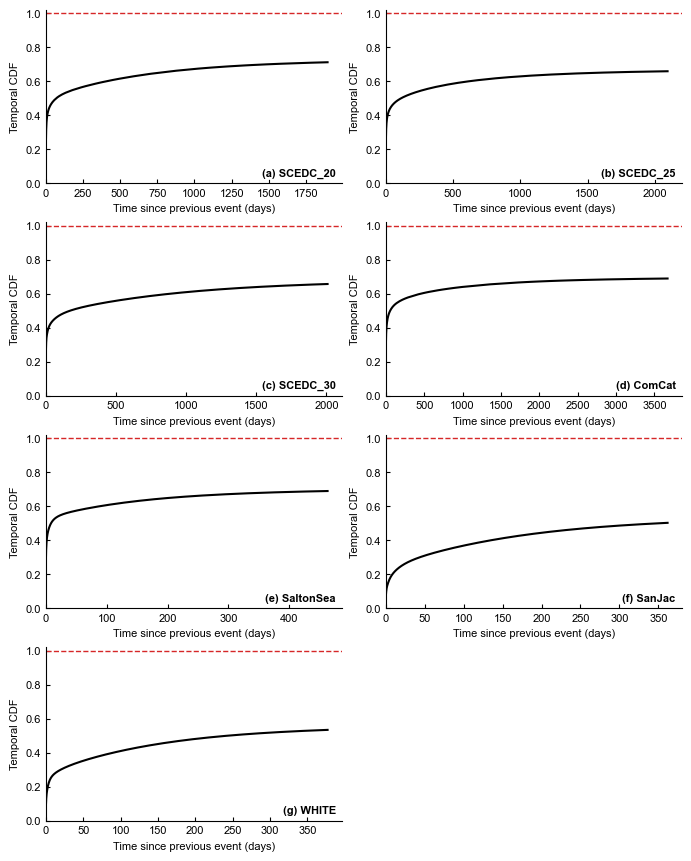

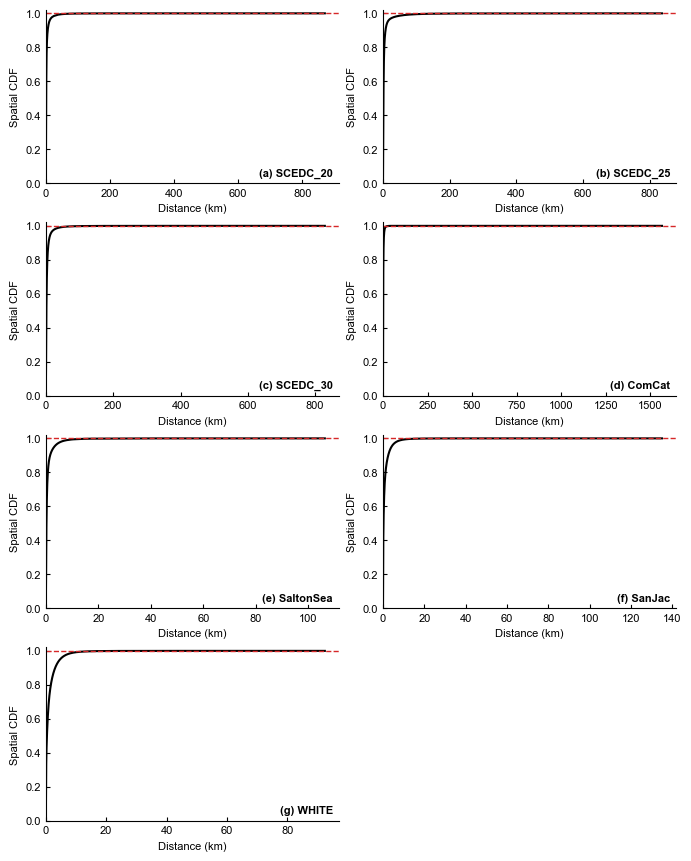

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import string

# ---------------- style ----------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

datasets = [
    "SCEDC_20",
    "SCEDC_25",
    "SCEDC_30",
    "ComCat",
    "SaltonSea",
    "SanJac",
    "WHITE",
]

letters = list(string.ascii_lowercase)

########################################################################
#                           Temporal Figure
########################################################################

fig, axes = plt.subplots(
    4,
    2,
    figsize=(6.8, 8.5),
    constrained_layout=True,
)

axes = axes.flatten()

for i, datasets_id in enumerate(datasets):

    cdf_temporal = np.load(
        f"results/{datasets_id}_neural_neural_neural_cdf_temporal_train.npy"
    )[::1000]

    delta_t = np.load(
        f"results/{datasets_id}_neural_neural_neural_dis_t_train.npy"
    )[::1000]

    ax = axes[i]

    ax.plot(
        delta_t,
        cdf_temporal,
        color="black",
        lw=1.5,
    )

    ax.axhline(
        1,
        color="tab:red",
        ls="--",
        lw=1,
    )

    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.02)

    # style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.98,
        0.03,
        f"({letters[i]}) {datasets_id}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5,
        ),
    )

    ax.set_xlabel("Time since previous event (days)")
    ax.set_ylabel("Temporal CDF")

fig.delaxes(axes[-1])

plt.savefig(
    "./fig/NKF_Temporal_CDF.pdf",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    "./fig/NKF_Temporal_CDF.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()


########################################################################
#                           Spatial Figure
########################################################################

fig, axes = plt.subplots(
    4,
    2,
    figsize=(6.8, 8.5),
    constrained_layout=True,
)

axes = axes.flatten()

for i, datasets_id in enumerate(datasets):

    cdf_spatial = np.load(
        f"results/{datasets_id}_neural_neural_neural_cdf_spatial_train.npy"
    )[::1000]

    delta_xy = np.load(
        f"results/{datasets_id}_neural_neural_neural_dis_xy_train.npy"
    )[::1000]

    ax = axes[i]

    ax.plot(
        delta_xy,
        cdf_spatial,
        color="black",
        lw=1.5,
    )

    ax.axhline(
        1,
        color="tab:red",
        ls="--",
        lw=1,
    )

    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.02)

    # style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.98,
        0.03,
        f"({letters[i]}) {datasets_id}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5,
        ),
    )

    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Spatial CDF")

fig.delaxes(axes[-1])

plt.savefig(
    "./fig/NKF_Spatial_CDF.pdf",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    "./fig/NKF_Spatial_CDF.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()